This notebook will go over my experience with chapter 2's topic: Supervised learning

As a reminder, supervised learning is used whenever we want to predict a certain outcome from a given input, and we have examples of input/output pairs

There are two types of supervised learning problems: **classifcation** and **regression**<br>
In **classification**, the goal is to classify or categorize a sample into a *predefined* class<br>
In **regression**, the goal is to predict a continuous number (e.g., a floating point number)

As an interesting note, we may expect simple models to generalize better to new data since they may have less rules<br>
It's a balance between **overfitting** and **underfitting**

It is key to note that model complexity is intimately tied to the variation of inputs contained in your training data.

In [1]:
#
# to avoid standard error messages containing full paths in my local machine
#
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load in the book's modules
# need this to import mglearn
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

(26, 2)


Text(0, 0.5, 'Second feature')

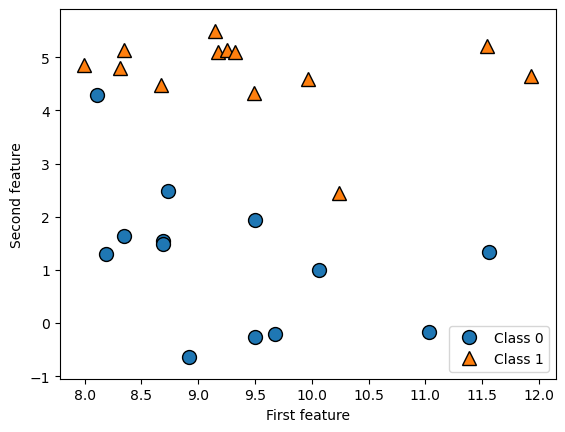

In [3]:
# create a dataset to get started
import matplotlib.pyplot as plt

x, y = mglearn.datasets.make_forge()
print(x.shape)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.legend(["Class 0", "Class 1"], loc = 4)
plt.xlabel("First feature")
plt.ylabel("Second feature")

Text(0, 0.5, 'Target')

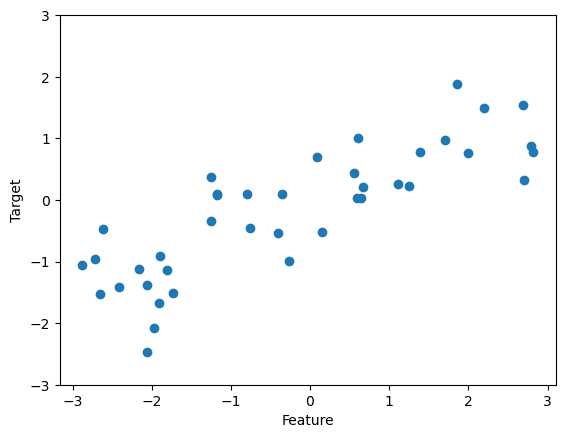

In [4]:
# just illustrating a very simple dataset
x, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(x, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")

In [5]:
# now to apply a classification test
import numpy as np
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.keys())
print(cancer.data.shape)
print({n: v for n,v in zip(cancer.target_names, np.bincount(cancer.target))})

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(569, 30)
{'malignant': 212, 'benign': 357}


In [6]:
# just loading some data that will be used for regression
from sklearn.datasets import load_boston
boston = load_boston()
print(boston.data.shape)

(506, 13)


In [7]:
# there is an issue with the boston data set so I guess I will go cali dataset
from sklearn.datasets import fetch_california_housing, fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)

In [8]:
# but buston is aviable locally?
x, y = mglearn.datasets.load_extended_boston()
print(x.shape)

import pandas as pd
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
boston = raw_df.values[1::2, 2]

(506, 104)


In [9]:
print(boston.data.shape)

(506,)


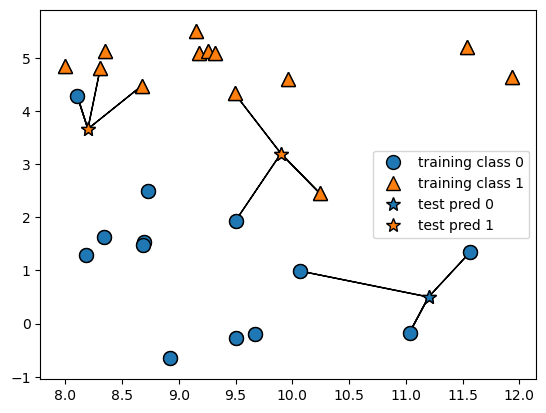

In [10]:
# knn is simple
mglearn.plots.plot_knn_classification(n_neighbors=1)
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [11]:
from sklearn.model_selection import train_test_split
x, y = mglearn.datasets.make_forge()
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)

In [12]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(xtrain, ytrain)
print(clf.predict(xtest))
print(clf.score(xtest, ytest))

[1 0 1 0 1 0 0]
0.8571428571428571


You will see that as we add more neighbors, the decision boundary tends to not follow the trained data as much (i.e., less neighbors, more following)

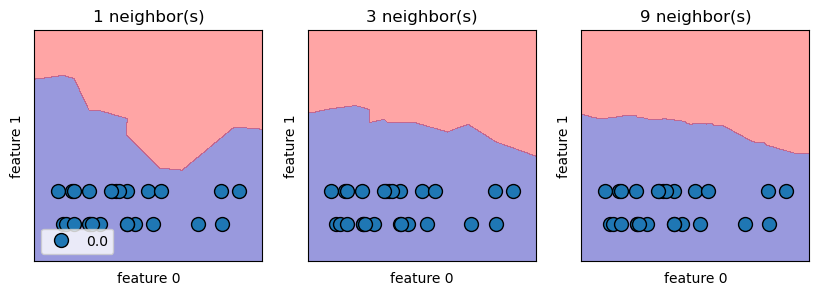

In [13]:
# plot
fig, axes = plt.subplots(1, 3, figsize = (10, 3))

for nneighbors, ax in zip([1, 3, 9], axes):
    clf = KNeighborsClassifier(n_neighbors=nneighbors).fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=True, eps=0.5, ax=ax, alpha = 0.4)
    mglearn.discrete_scatter(x[:,0], y, ax = ax)
    ax.set_title(f"{nneighbors} neighbor(s)")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc = 3)

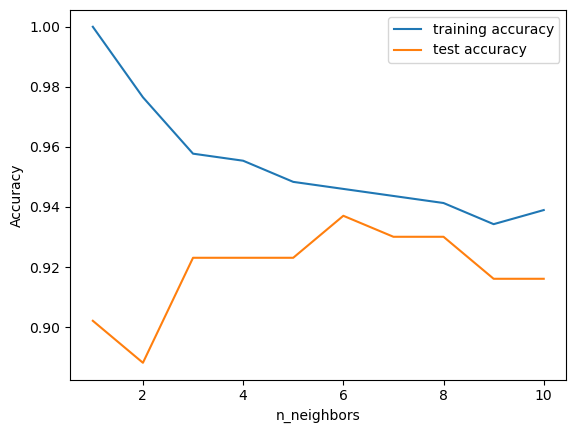

In [14]:
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)
train_accuracy = list()
test_accuracy  = list()
nei_settings   = range(1, 11)

for nnei in nei_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=nnei)
    clf.fit(xtrain, ytrain)
    train_accuracy.append(clf.score(xtrain, ytrain)) # record training set accuracy
    test_accuracy.append(clf.score(xtest, ytest))    # record generalization accuracy

plt.plot(nei_settings, train_accuracy, label = "training accuracy")
plt.plot(nei_settings, test_accuracy, label = "test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend() # performance tends to be best somewhere in the middle

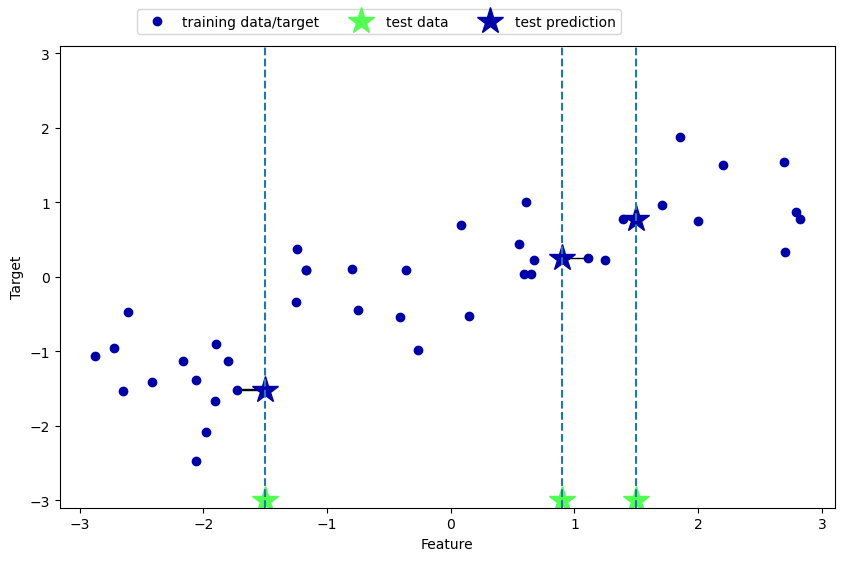

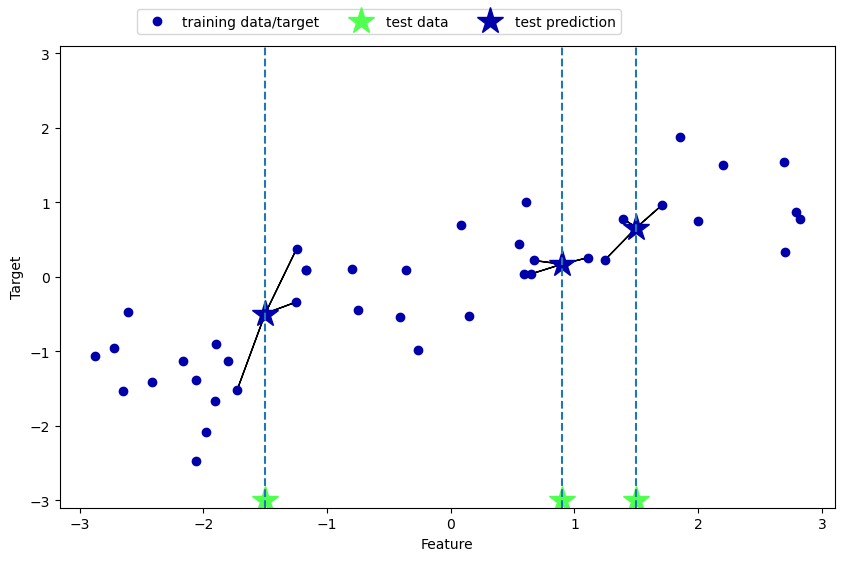

In [15]:
# doing a regression variant of the k-nearest neighbors algorithm
mglearn.plots.plot_knn_regression(n_neighbors=1)
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [16]:
# doing it more manually
from sklearn.neighbors import KNeighborsRegressor
x, y = mglearn.datasets.make_wave(n_samples=40)

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(xtrain, ytrain)
print(reg.predict(xtest))
print(reg.score(xtest, ytest))


[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
0.8344172446249605


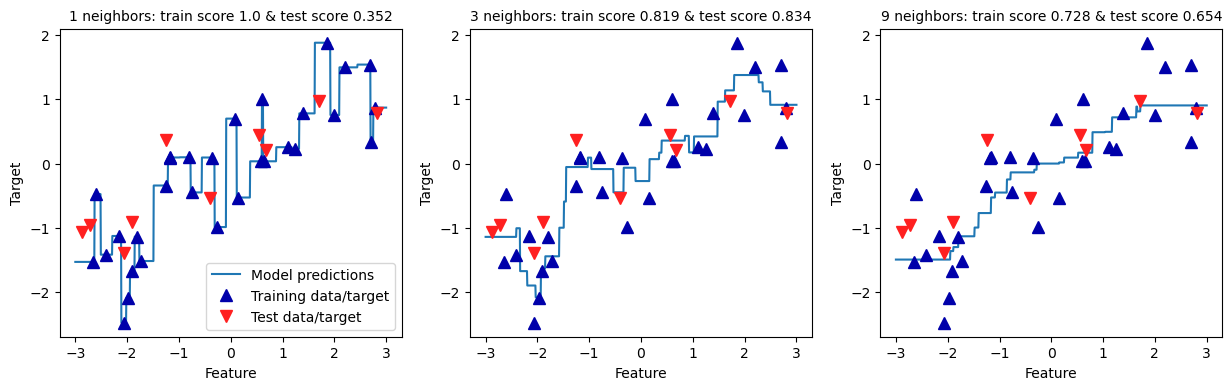

In [17]:
# to plot across multiple values
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
line      = np.linspace(-3, 3, 1_000).reshape(-1, 1) # create 1,000 data points evenly spaced between -3 & 3
for nnei, ax in zip([1, 3, 9], axes):
    reg = KNeighborsRegressor(n_neighbors=nnei)
    reg.fit(xtrain, ytrain)
    ts = round(reg.score(xtrain, ytrain), 3)
    Ts = round(reg.score(xtest, ytest), 3)
    ax.plot(line, reg.predict(line))
    ax.plot(xtrain, ytrain, '^', c = mglearn.cm2(0), markersize = 8) 
    ax.plot(xtest, ytest, 'v', c = mglearn.cm2(1), markersize = 8) 
    ax.set_title(f"{nnei} neighbors: train score {ts} & test score {Ts}", fontsize = 10)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target","Test data/target"], loc = "best")

w[0]: 0.393906  b: -0.031804


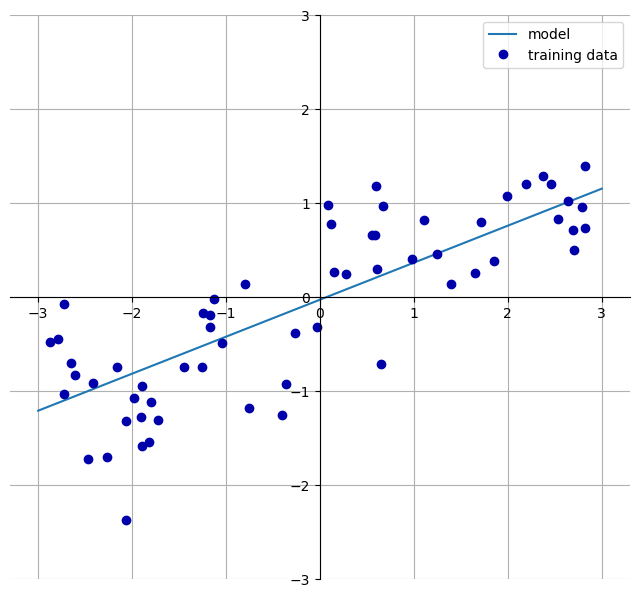

In [18]:
# here are the learned parameters based on a linear regression
mglearn.plots.plot_linear_regression_wave()

In [19]:
# now to go over a linear regression (aka ordinary least squares)
from sklearn.linear_model import LinearRegression
x, y = mglearn.datasets.make_wave(n_samples=60)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42)

lr = LinearRegression().fit(xtrain, ytrain) # remember, linear regression is parameters free

In [20]:
print(lr.coef_)
print(lr.intercept_)

[0.39390555]
-0.03180434302675973


In [21]:
print("Training", lr.score(xtrain, ytrain))
print("Testing", lr.score(xtest, ytest))

Training 0.6700890315075756
Testing 0.6593368596863701


# Ridge regression
In a ridge regression, the coefficients are chosen not only so that they predict well on the training data, but also to fit an additional constraint. It is also good to keep the magnitude of coefficients to be as small as possible (i.e., all entries of *w* should be close to zero). This means each feature should have as little effect on the outcome as possible while still predicting well

This is called **regularization**, which is used to restrict a model to avoid overfitting

In [22]:
from sklearn.linear_model import Ridge
ridge = Ridge() # didn't do this cause it requires the boston dataset...

# STOP AT PAGE 53

# Lasso
Lasso is a similar approach to a ridge regression, since it also restricts coefficients to be close to zero. However, it applies an L1 regularization algorithm which causes some coefficients to be exactly zero. This means some features are entirely ignored by the model. This can make the model easier to interpret & reveal the most important features

In [23]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(xtrain, ytrain)
print(lasso.score(xtrain, ytrain))
print(lasso.score(xtest, ytest))
print(np.sum(lasso.coef_ != 0)) # this is not good; again used a different data set since boston has been removed

0.2852883107043638
0.23759680165114305
1


In [24]:
# the above illustrates a case of underfitting. We can adjust the alpha (how strongly coefficients are pushed toward zero)
# if we do not want to change alpha, we can also tweak the maximum number of iterations to run
lasso001 = Lasso(alpha=0.01, max_iter=100_000).fit(xtrain, ytrain)
print(lasso001.score(xtrain, ytrain))
print(lasso001.score(xtest, ytest))
print(np.sum(lasso001.coef_ != 0))

0.6700505514354953
0.6575601699825229
1


In [25]:
# over fitting can occur if we lower the alpha & remove the effect of regularization
lasso0001 = Lasso(alpha=0.0001, max_iter=100_000).fit(xtrain, ytrain)
print(lasso0001.score(xtrain, ytrain))
print(lasso0001.score(xtest, ytest))
print(np.sum(lasso0001.coef_ != 0))

0.6700890276595685
0.6593193368604192
1


Text(0, 0.5, 'Coefficinet magnitude')

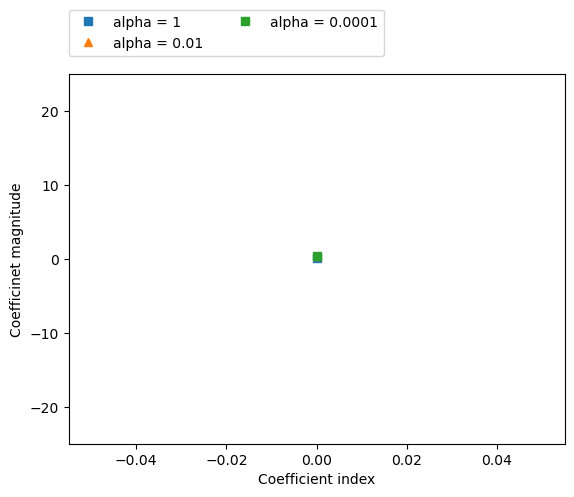

In [26]:
# plot the coefficients of different models

# I didn't use the right data set for this :(
plt.plot(lasso.coef_, 's', label = "alpha = 1")
plt.plot(lasso001.coef_, '^', label = "alpha = 0.01")
plt.plot(lasso0001.coef_, 's', label = "alpha = 0.0001")
plt.legend(ncol = 2, loc = (0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficinet magnitude")

The two most common linear classification algorithms are **logistic regression** and **linear support vector machines**

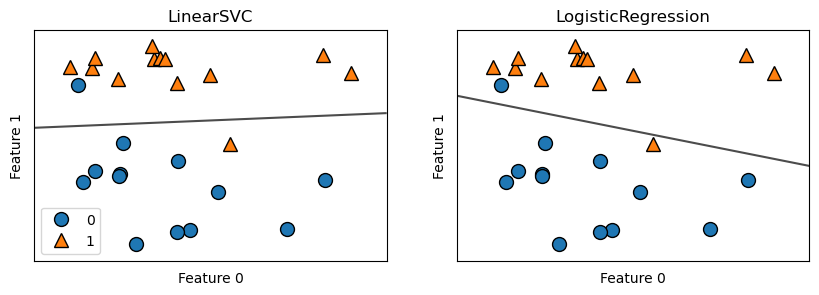

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

x, y = mglearn.datasets.make_forge()
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for model, ax in zip([LinearSVC(max_iter=10_000), LogisticRegression(max_iter=10_000)], axes):
    clf = model.fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=False, eps=0.5, ax=ax, alpha=.7)
    mglearn.discrete_scatter(x[:, 0], x[:, 1], y, ax=ax)
    ax.set_title("{}".format(clf.__class__.__name__))
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
axes[0].legend()

From the figure above, we can see where the decision boundary is set. The trade-off parameter that determines the strength of the regularization is called **C**, and higher values of **C** correspond to *less* regularization. Meaning, when you use a high value of **C**, the models will try to fit the training set as best as possible, while low values allow the models to place more emphasis on fidning a coefficient vector that is close to zero.

Inheritetly, higher values of **C** stresses the importance that each individual data point can be classified correctly instead of just trying to adjust the majority of points

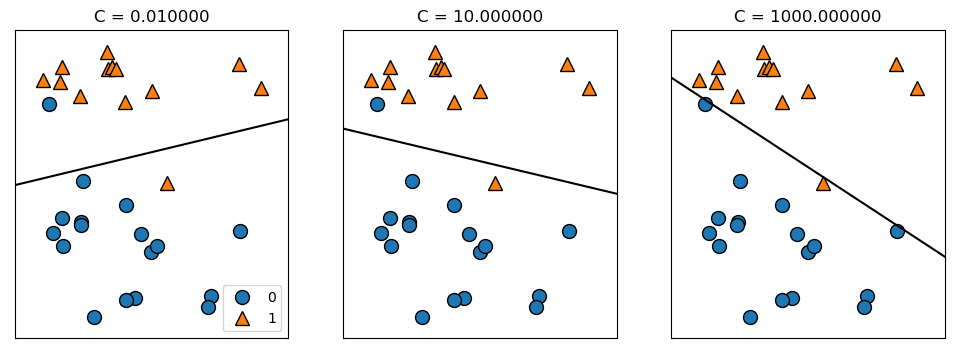

In [28]:
mglearn.plots.plot_linear_svc_regularization()

As *C** increases, the model tries harder to fit the two points misclassified at lower **C** values. For this data set, a linear model may not be the best approach

In [29]:
# looking at LinearLogistic
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target,
                                                stratify=cancer.target, random_state=42)
logreg = LogisticRegression().fit(xtrain, ytrain)
print(logreg.score(xtrain, ytrain))
print(logreg.score(xtest, ytest))

0.9460093896713615
0.958041958041958


In [30]:
# increase C in an already good model
logreg100 = LogisticRegression(C=100).fit(xtrain, ytrain)
print(logreg100.score(xtrain, ytrain))
print(logreg100.score(xtest, ytest))

0.9483568075117371
0.958041958041958


In [31]:
# barely an improvement, but still an improvement?

# showing a worse model
logreg001 = LogisticRegression(C=0.01).fit(xtrain, ytrain)
print(logreg001.score(xtrain, ytrain))
print(logreg001.score(xtest, ytest))

0.9342723004694836
0.9300699300699301


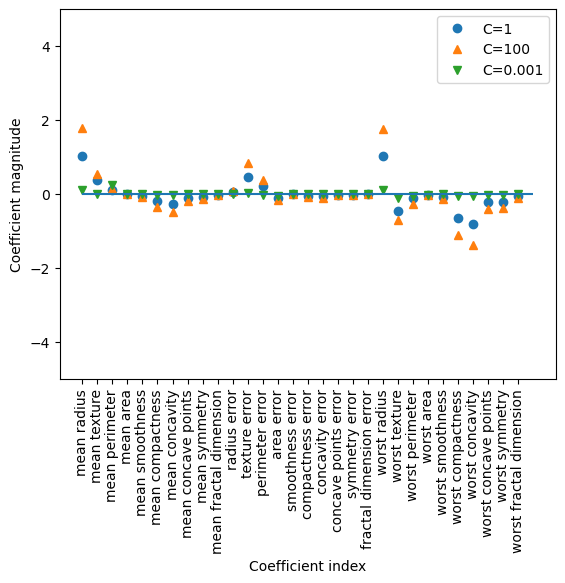

In [32]:
plt.plot(logreg.coef_.T, 'o', label="C=1")
plt.plot(logreg100.coef_.T,
'^'
, label="C=100")
plt.plot(logreg001.coef_.T, 'v', label="C=0.001")
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.legend()

# for C = 1 & 100, coefficients tend to lean negative

Training accuracy of l1 logreg with C=0.001: 0.94
Test accuracy of l1 logreg with C=0.001: 0.93
Training accuracy of l1 logreg with C=1.000: 0.95
Test accuracy of l1 logreg with C=1.000: 0.96
Training accuracy of l1 logreg with C=100.000: 0.95
Test accuracy of l1 logreg with C=100.000: 0.96


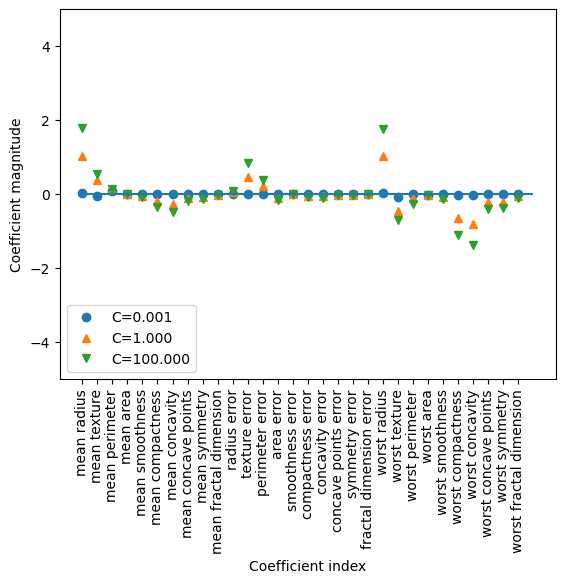

In [33]:
# to produce a more interpretable model, use L1 regularization, which will use only. a few of the feature

# igot an error trying l1 penalty, so I did l2 to get it to run
for C, marker in zip([0.001, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty="l2").fit(xtrain, ytrain)
    print("Training accuracy of l1 logreg with C={:.3f}: {:.2f}".format(C, lr_l1.score(xtrain, ytrain)))
    print("Test accuracy of l1 logreg with C={:.3f}: {:.2f}".format(C, lr_l1.score(xtest, ytest)))
    plt.plot(lr_l1.coef_.T, marker, label="C={:.3f}".format(C))
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5, 5)
plt.legend(loc=3)

# Linear models for multiclass classification
A common technique to extend a binary classification algorithm ito a multiclass algorithm is the **one-vs.-rest** approach

In the one-vs.-rest approach, a binary model is learned for each class that tries to seperate that class from all the other classes, resulting in as many binary models as there are classes To make a prediction, all binary classifiers are run on a test point. The classifier that has the highest score on its single class "wins", and this class label is returned as the prediction

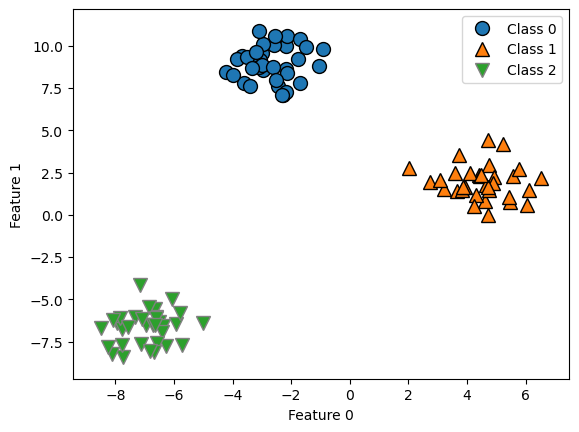

In [34]:
# applying the one-vs.-rest approach

# just looking at the data
from sklearn.datasets import make_blobs
x, y = make_blobs(random_state=42)
mglearn.discrete_scatter(x[:, 0], x[:,1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1", "Class 2"])

In [35]:
# train the model
linear_svm = LinearSVC().fit(x, y)
print(linear_svm.coef_.shape)
print(linear_svm.intercept_.shape) # this should resemble what we see above

(3, 2)
(3,)


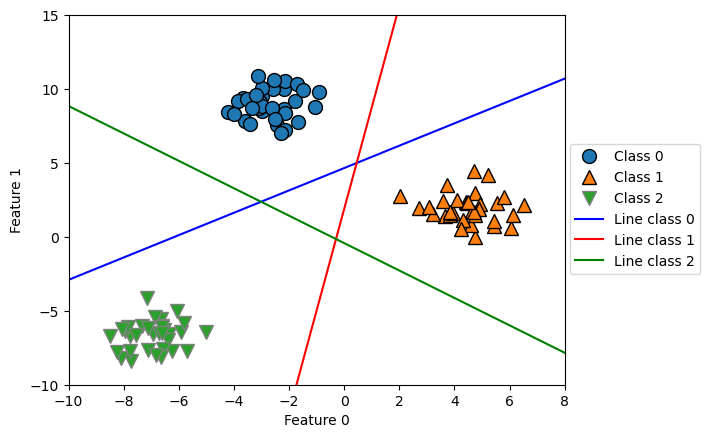

In [36]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1', 'Line class 2'], loc=(1.01, 0.3))

Text(0, 0.5, 'Feature 1')

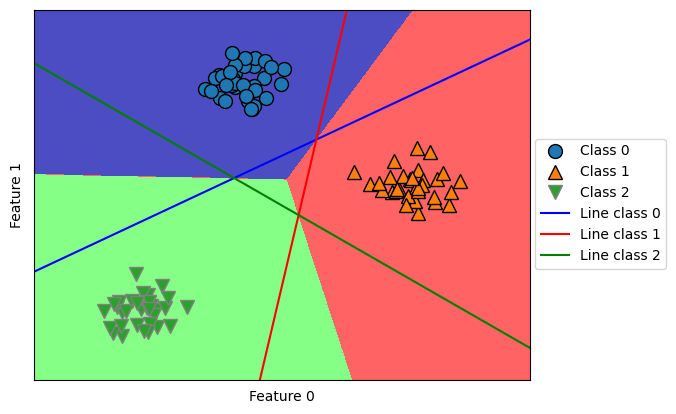

In [37]:
mglearn.plots.plot_2d_classification(linear_svm, x, fill=True, alpha=.7)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1', 'Line class 2'], loc=(1.01, 0.3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The main parameter of linear models is the regularization parameter, called *alpha* in the regression models and *C* in Linear SVC/Regression.

L2 vs L1, L1 is useful if you assume only a few features matters. Else, L2 is where you should start

# Naive Bayes Classifiers
Naive Bayes classifiers tend to be faster than linear models at training, but often provide generalization performance that is slightly worse. They are efficient because they learn parameters by looking at each feature individually & collect simple per-class stastisics from each feature

## Gaussian
Can be applied on continuous data

## Bernoulli
Can be applied on binary data

## Multinomial
Can be applied on count data

Bernoulli & Multinomial are mostly used in text data classification


In [38]:
# simulate data
x = np.array([[0, 1, 0, 1], [1, 0, 1, 1],
              [0, 0, 0, 1], [1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

# four data points with 4 features each
counts = {label : x[y == label].sum(axis = 0) for label in np.unique(y)}
print(counts)

{0: array([0, 1, 0, 2]), 1: array([2, 0, 2, 1])}


Multinomial takes into account the average value for each feature for each class, while Gaussian stores the average value and the standard deviation for each feature for each class

Multinomial & Bernoulli have a single parameter, *alpha*, which controls model complexity. The way *alpha* works is that the algorithm adds to the data *alpha* many virtual data points that have positive values for all the features. This results in a *smoothing* of the statistics. This doesn't really impact performance, more for accuracy

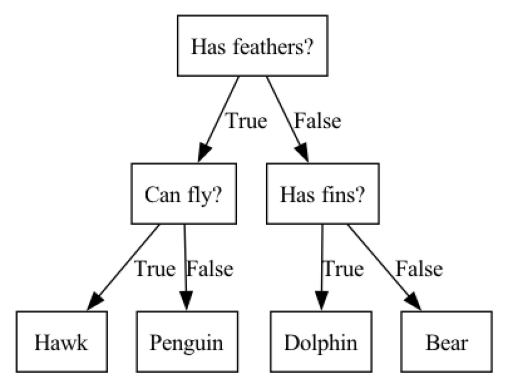

In [39]:
# Decision trees
mglearn.plots.plot_animal_tree()

Learning a decision tree means learning the sequence of if/else questions that get us to the true answer most quickly. Formally, these questions are known as *tests*

A lear of a decision tree that contains data points that all share the same target value is called *pure*. 

Building decision trees can easily lead to overfitting your data. You can prune the tree at different stages to avoid overfitting (pre or post pruning). A decision tree with all its leaves being pure may be a sign of overfitting.

In [40]:
# the current library only does pre-pruning
from sklearn.tree import DecisionTreeClassifier
cancer = load_breast_cancer()
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(xtrain, ytrain)
print(tree.score(xtrain, ytrain))
print(tree.score(xtest, ytest))

1.0
0.9370629370629371


In [41]:
# overfitted. We can control this by controlling the depth of the tree
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(xtrain, ytrain)
print(tree.score(xtrain, ytrain))
print(tree.score(xtest, ytest))

0.9882629107981221
0.951048951048951


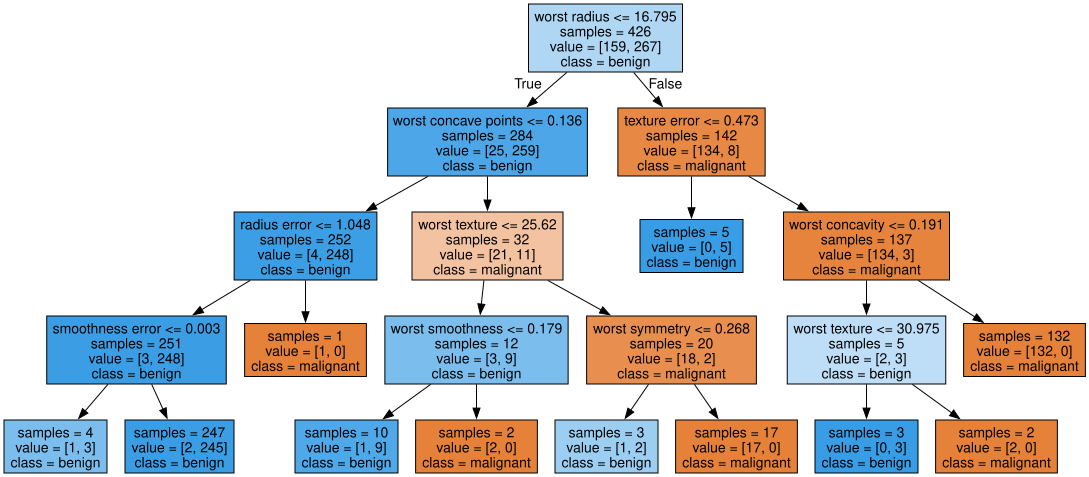

In [42]:
# see the tree
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file="tree.dot", class_names=["malignant", "benign"], feature_names=cancer.feature_names, impurity=False, filled=True)


import graphviz
with open("tree.dot") as fh:
    dot_graph = fh.read()
graphviz.Source(dot_graph)


The samples = *N* above shows how many samples went down that path/were in that node

A nice way of understanding a decision tree is by looking at the feature importance (which features had the most influence)

In [43]:
print(tree.feature_importances_)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


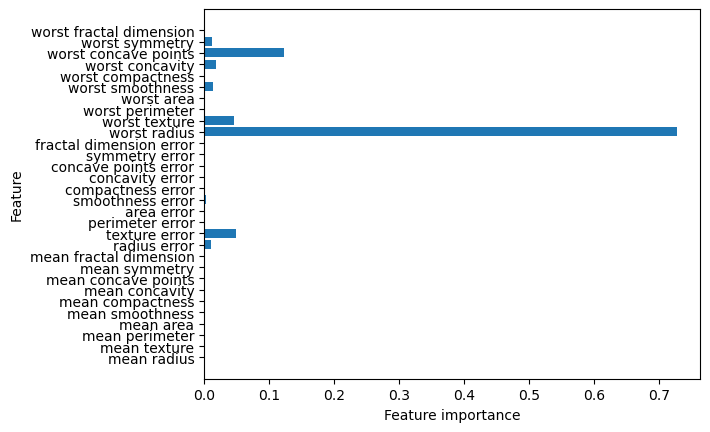

In [44]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
plot_feature_importances_cancer(tree)

## NOTE
If a feature has low feature importance, it doesn't mean that this feature is uninformative. It only means that the feature was not picked by the tree, likely because another feature encodes the same information.

Feature importances: [0. 1.]


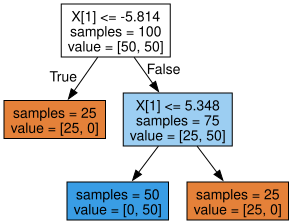

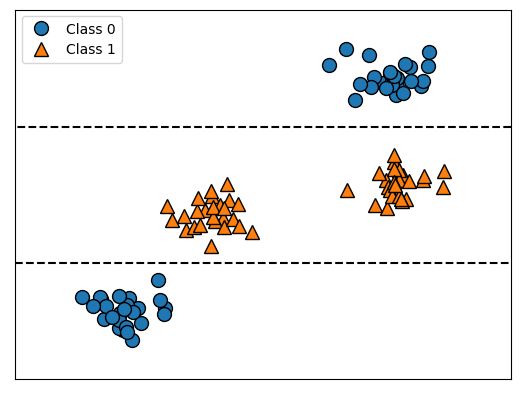

In [45]:
# see the coeffients
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

Here is an example where the output class is not *monotonous*, meaning we cannot say a high value of *X* means class 0, and a low value means class 1

In tree-based models for regression it is important to point out that these models cannot *extraplolate* (make predictions outside of the range of the training data)

Text(0, 0.5, 'Price in $/Mbyte')

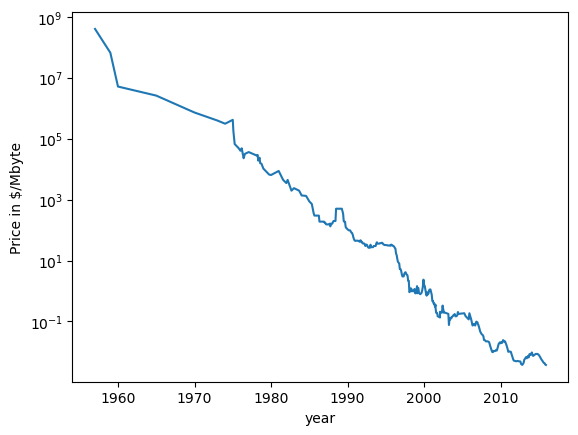

In [46]:
import pandas as pd
ram_prices = pd.read_csv("../introduction_to_ml_with_python/data/ram_price.csv")
plt.semilogy(ram_prices.date, ram_prices.price) # create a plot with a log-scale y-axis and a linear scale-scale x-axis
plt.xlabel("year")
plt.ylabel("Price in $/Mbyte")

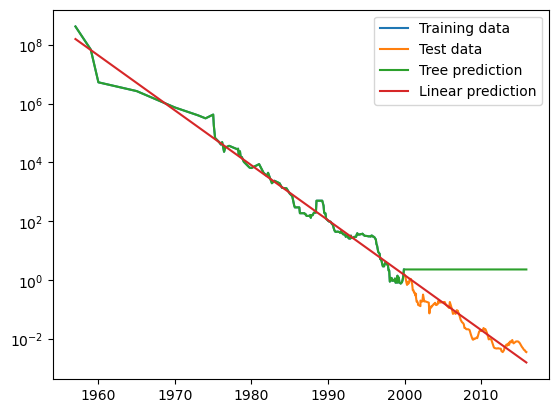

In [47]:
#
#   forcast prices for the years after 2000
#   log scale makes the trend look linear, so this may impact model selection
#   going to tree a decision tree regression & linear regression
#
from sklearn.tree import DecisionTreeRegressor
data_train = ram_prices[ram_prices.date < 2000]
data_test  = ram_prices[ram_prices.date >= 2000]
xtrain     = data_train.date[:, np.newaxis]
ytrain     = np.log(data_train.price)

# train the models
tree       = DecisionTreeRegressor().fit(xtrain, ytrain)
linear_reg = LinearRegression().fit(xtrain, ytrain)

# predict
xall      = ram_prices.date[:, np.newaxis]
pred_tree = tree.predict(xall)
pred_lr   = linear_reg.predict(xall)

# undo log transformation
price_tree = np.exp(pred_tree)
price_lr   = np.exp(pred_lr)


# view
plt.semilogy(data_train.date, data_train.price, label="Training data")
plt.semilogy(data_test.date, data_test.price, label="Test data")
plt.semilogy(ram_prices.date, price_tree, label="Tree prediction")
plt.semilogy(ram_prices.date, price_lr, label="Linear prediction")
plt.legend()


The issue here is that the decision tree makes perfect predictions on the training data (over fitting due to no pruning or controlling of model complexity) and cannot generate "new" responses for predictions

A good property of decision trees is that data doesn't need to be preprocessed (e.g., normalized or standardized)

# ENSEMBLES
**Ensembles** are methods that combine multiple machine learning models to create more powerful models

Two examples are **random forests** and **gradient boosted decision trees**

A **random forest** is essentially a collection of decision trees, where each. tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job predicting, but will likely overfit on part of the data. If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results

They are called random because the algorithm injects randomness into the tree building process to ensure each tree is different. There are two ways of doing this.
  - by selecting the data points used to build a tree (e.g., through a bootstrapping approach)
  - by selecting features in each split test (e.g., each node randomly selects a feature to test)

A good rule of thume is to set the max number of features for each tree as the square root of the total number of available features

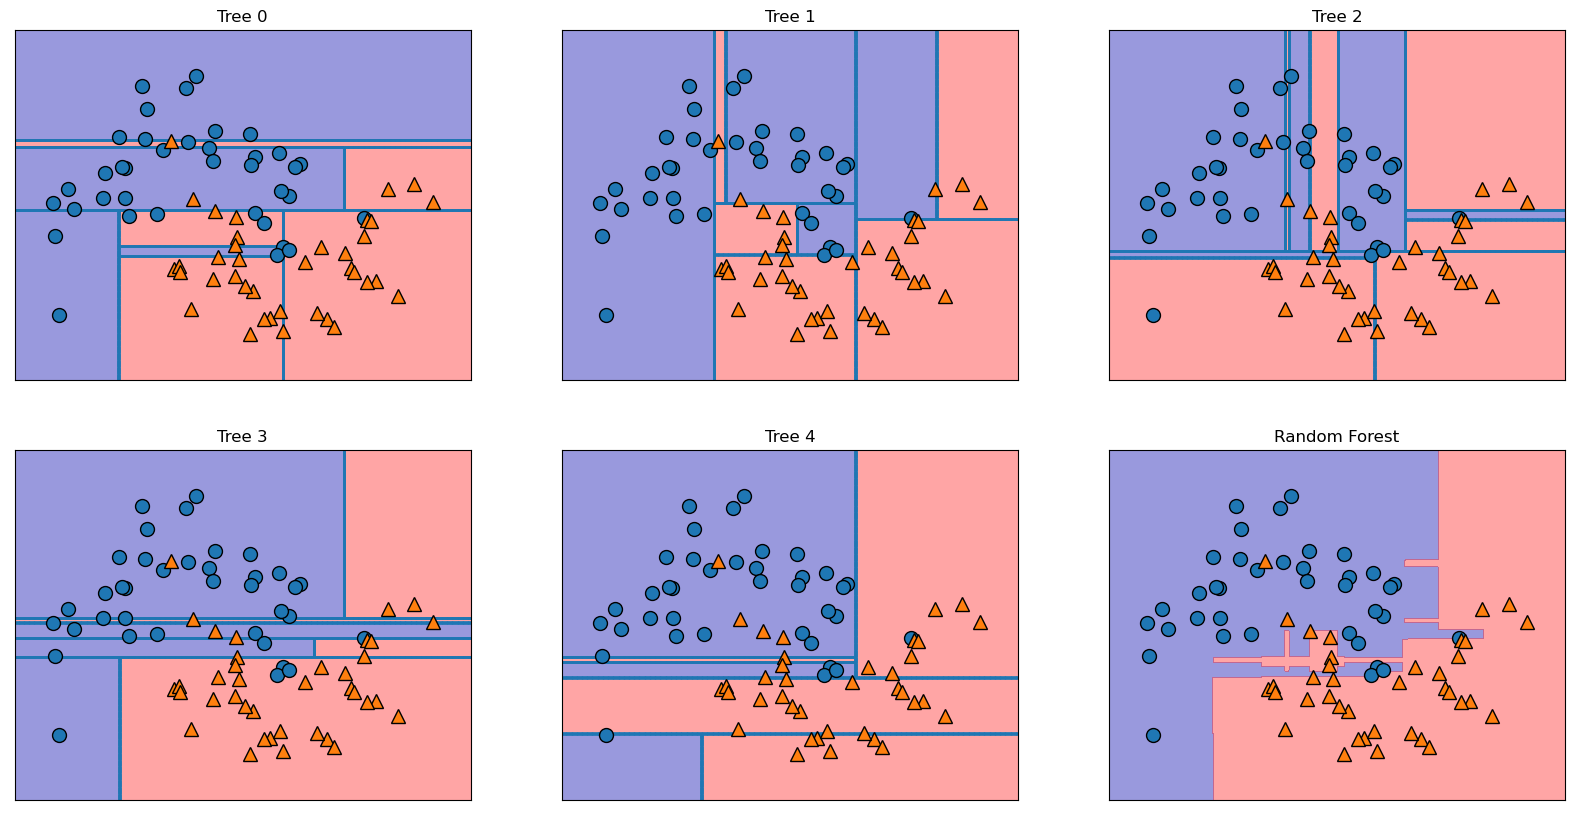

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.25, random_state=3)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, stratify=y, random_state=42)
forest = RandomForestClassifier(n_estimators=5, random_state=2) # 5 trees
forest.fit(xtrain, ytrain)

# now visualie the boundaries learned from each tree
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(xtrain, ytrain, tree, ax=ax)

mglearn.plots.plot_2d_separator(forest, xtrain, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title("Random Forest")
mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain)

1.0
0.958041958041958


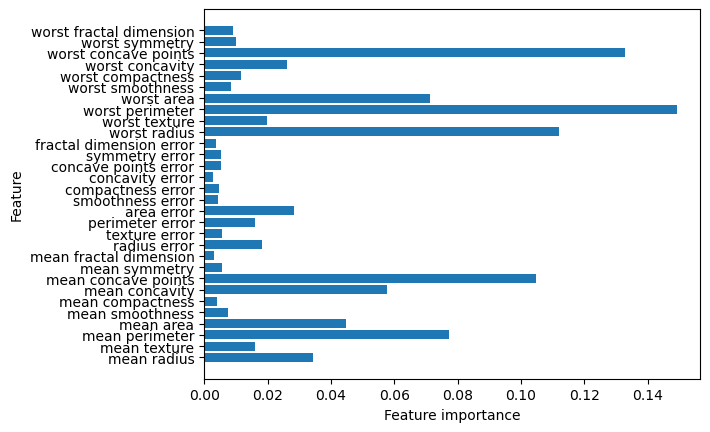

In [49]:
# try it on the cancer data set
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(xtrain, ytrain)
print(forest.score(xtrain, ytrain))
print(forest.score(xtest, ytest))

plot_feature_importances_cancer(forest)

In **gradient boosted regression trees**, the algorithm works by building trees in a serial manner, where each tree tries to correct the mistakes of the previous one. By default, there is no randomization in gradient boosted regression trees, but instead, a strong pre-pruning is used. These trees also tend to be very shallow.

The idea behind this to to combine many simple models (i.e., **weak learners**) and iteratively improve performance. They are more sensitive than random forest to parameters, but can provide better accuracy if set correctly. A key parameter is the **learning rate**, which controls how strongly each tree tries to correct the mistakes of the previous trees.

The more trees, the more complex the ensemble will be since more trees means more individual corrections. So more trees can lead to overfitting, which makes these models tricky to train

In [50]:
from sklearn.ensemble import GradientBoostingClassifier
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, random_state=0)
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(xtrain, ytrain)

print(gbrt.score(xtrain, ytrain))
print(gbrt.score(xtest, ytest))

1.0
0.965034965034965


In [51]:
# reduce complexity and overfitting
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(xtrain, ytrain)

print(gbrt.score(xtrain, ytrain))
print(gbrt.score(xtest, ytest))

0.9906103286384976
0.972027972027972


In [52]:
# reduce learning rate
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt.fit(xtrain, ytrain)

print(gbrt.score(xtrain, ytrain))
print(gbrt.score(xtest, ytest))

0.9882629107981221
0.965034965034965


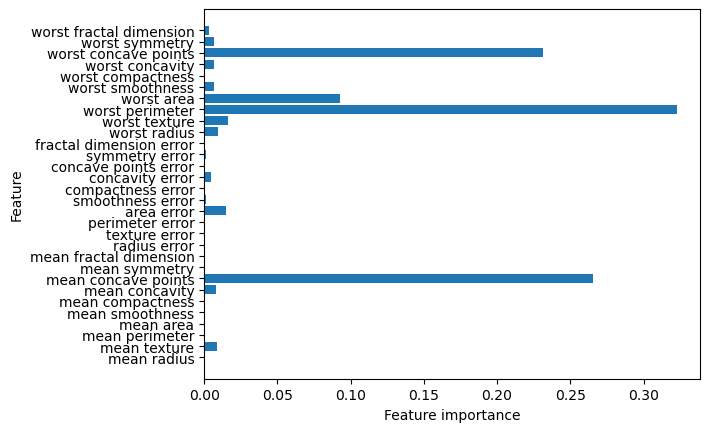

In [53]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(xtrain, ytrain)
plot_feature_importances_cancer(gbrt)

# Kernelized Support Vector Machines
These elements are an extension that allows for more complex models that are not defined by hyperplanes in the input space. There are both classification & regression variants

The idea is to take data that isn't linearly separable in its original space, map it into a higher-dimensional space where it *becomes* linearly separable, and find a linear separator there.

The clever part is that you never actually have to compute this high-dimensional mapping explicitly. SVM math only requires computing dot products between pairs of data points. A **kernel function** lets you compute what the dot product *would* be in the higher-dimensional space, directly from the original data without ever transforming the points. This it the *kernel trick*.

Common kernel variants
- **Linear kernel**: equivalent to a standard linear SVM
- **Polynomial kernel**: captures interactions up to some degree
- **Radial Basis Function (RBF)/ Gaussian kernel**: maps to an infinite-dimensional space, extremely popular because it can model very flexible, non-linear boundaries
- **Sigmold kernel**: behaves similarly to a neural network activation function


Some good to knows:
- **Parameters**: learned automatically by the training process (e.g., a slope or intercept in a linear model). The algorithm figures out their values by fitting to the data
- **Hyperparameters**: chosen by you (or by some separate tuning process) beforehand. They control *how* the learning happens. The model never *learns* these from the data directly.

Text(0, 0.5, 'feat. 1')

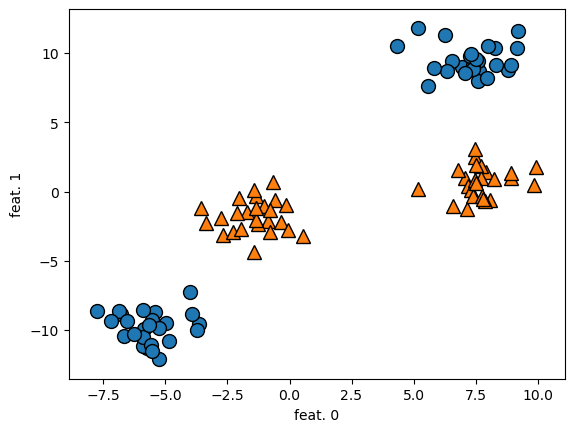

In [54]:
# illustrate a case where drawing a single boundary would not work
x, y = make_blobs(centers=4, random_state=8)
y    = y % 2
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("feat. 0")
plt.ylabel("feat. 1")

Text(0, 0.5, 'Feature 1')

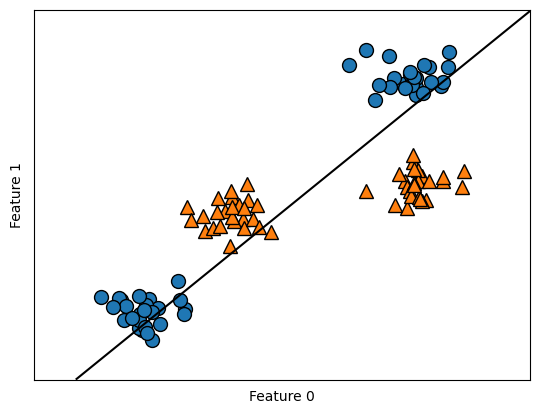

In [55]:
# trying to fit a linear model to this
from sklearn.svm import LinearSVC

linear_svm = LinearSVC().fit(x, y)
mglearn.plots.plot_2d_separator(linear_svm, x)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0.5, 0, 'feature1^2')

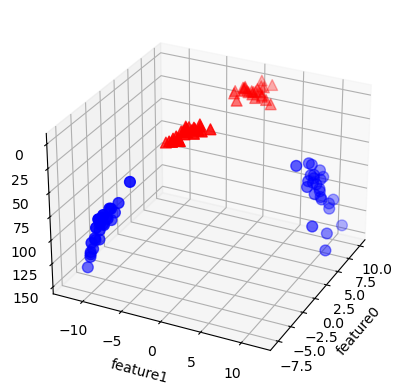

In [56]:
# introduce a third feature to increase the dimensionality of the data
from mpl_toolkits.mplot3d import Axes3D, axes3d

xnew   = np.hstack([x, x[:,1:]**2]) # feature 1^2
mask   = y == 0
figure = plt.figure()
ax     = figure.add_subplot(111, projection='3d', elev=-152, azim=-26) # modern way? 111 is a three digit code (1 row, 1 column, index [r,c])
# ax     = Axes3D(figure, elev = -152, azim = -26)
ax.scatter(xnew[mask, 0], xnew[mask, 1], xnew[mask, 2], c = 'b', cmap=mglearn.cm2, s = 60)
ax.scatter(xnew[~mask, 0], xnew[~mask, 1], xnew[~mask, 2], c = 'r', cmap=mglearn.cm2, s = 60, marker='^')
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1^2")

Text(0.5, 0, 'feature0 ** 2')

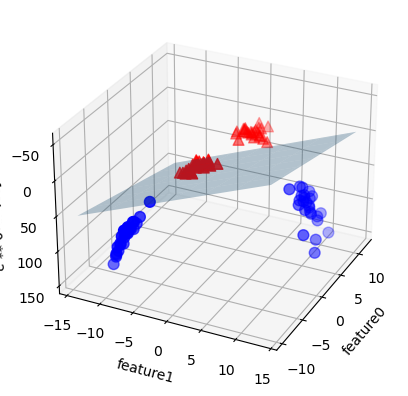

In [57]:
# now put a single boundary here
linear_svm_3d   = LinearSVC().fit(xnew, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

# plot
figure = plt.figure()
ax     = figure.add_subplot(111, projection='3d', elev=-152, azim=-26)
xx     = np.linspace(xnew[:, 0].min() - 2, xnew[:, 0].max() + 2, 50)
yy     = np.linspace(xnew[:, 1].min() - 2, xnew[:, 1].max() + 2, 50)
xx, yy = np.meshgrid(xx, yy)
zz     = (coef[0] * xx + coef[1] * yy + intercept) / -coef[2]
ax.plot_surface(xx, yy, zz, rstride=8, cstride=8, alpha=0.3)
ax.scatter(xnew[mask, 0], xnew[mask, 1], xnew[mask, 2], c='b', cmap=mglearn.cm2, s=60)
ax.scatter(xnew[~mask, 0], xnew[~mask, 1], xnew[~mask, 2], c='r', marker='^', cmap=mglearn.cm2, s=60)
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature0 ** 2")


Text(0, 0.5, 'Feature 1')

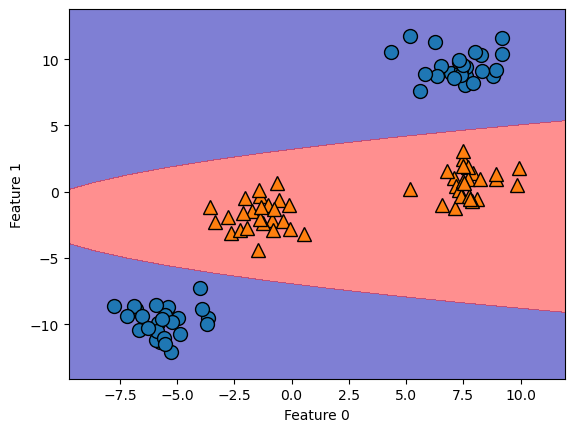

In [58]:
# the "line" really is more like an ellipse
zz  = yy ** 2
dec = linear_svm_3d.decision_function(np.c_[xx.ravel(), yy.ravel(), zz.ravel()])
plt.contourf(xx, yy, dec.reshape(xx.shape), levels=[dec.min(), 0, dec.max()], cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The lesson here is that adding nonlinear features to the representation of our data can make linear models much more powerful.

Vectors that lie on the border between the two classes are known as **support vectors**, which give these ensembles their name. To make a prediction for a new point, the distance to each of the support vectors is measured.

Text(0, 0.5, 'Feature 1')

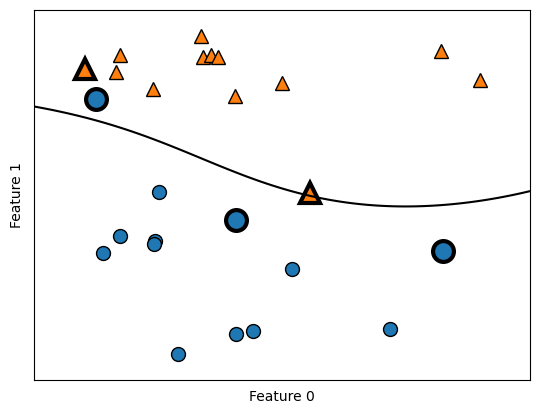

In [59]:
from sklearn.svm import SVC

x, y = mglearn.tools.make_handcrafted_dataset()
svm  = SVC(kernel='rbf', C=10, gamma=0.1).fit(x, y) # radial basis kernel function (i.e., gaussian kernel)

mglearn.plots.plot_2d_separator(svm, x, eps=.5)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The *gamma* parameter used above controls the width of the Gaussian kernel (i.e., it determines the scale of what it means for points to be close together)
The **C** parameter is a regularization parameter. It limits the importance for each point

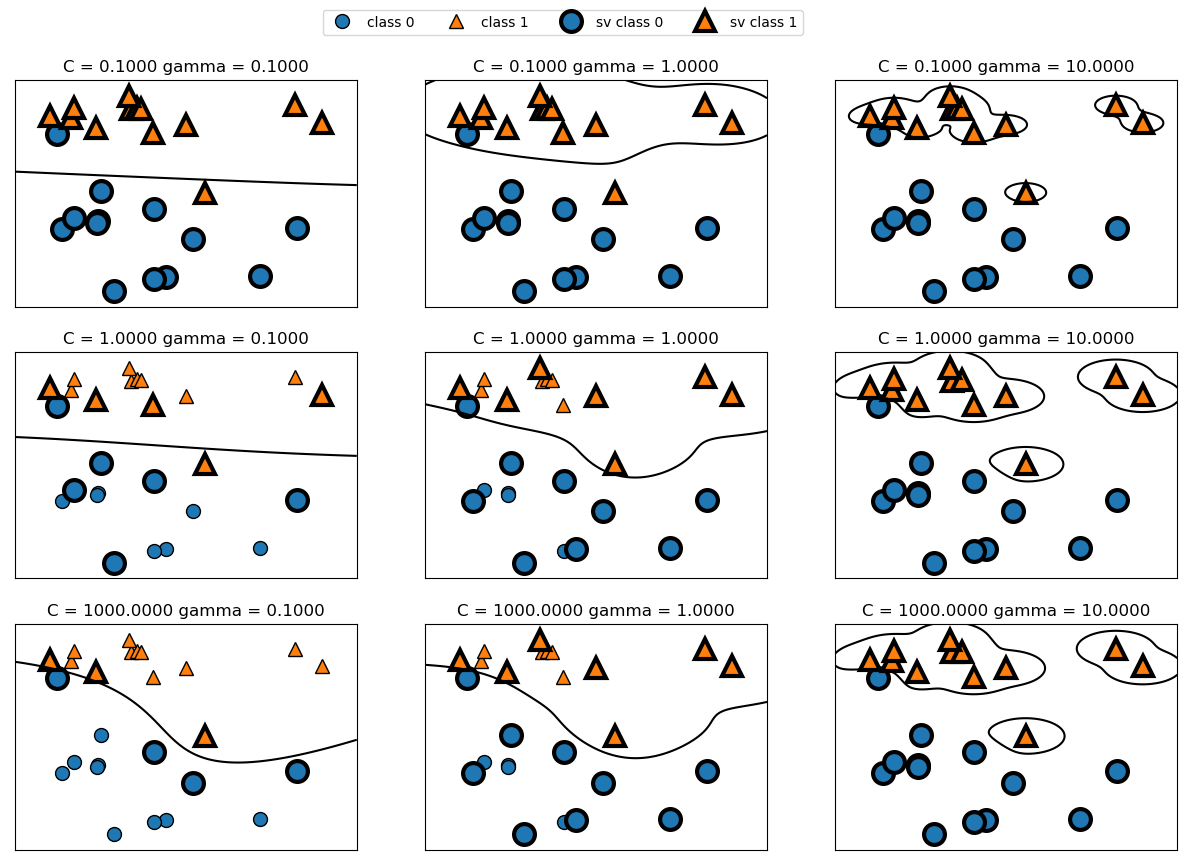

In [60]:
# visualize how these two parameters influence the model

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)
axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
ncol=4, loc=(.9, 1.2))

A small gamma means a large radius for the Gaussian kernel, which means that many points are considered close by. This is reflected in very smooth decision boundaries on the left, and boundaries that focus more on single points further to the right. Higher gamma values, the more complex the model

In [61]:
# try rbf method on cancer
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, random_state=0)
svc = SVC()
svc.fit(xtrain, ytrain)
print(svc.score(xtrain, ytrain))
print(svc.score(xtest, ytest))

0.903755868544601
0.9370629370629371


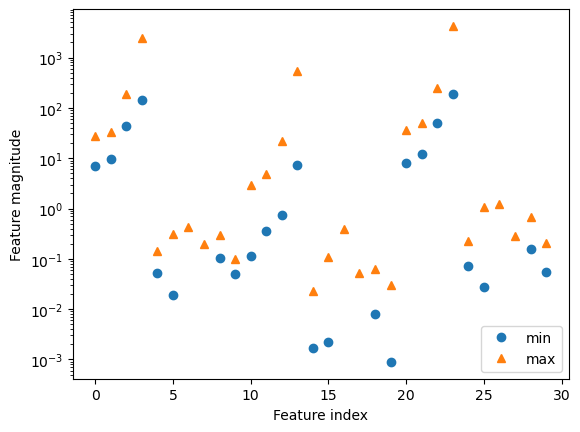

In [62]:
# the above is over fitted
plt.plot(xtrain.min(axis=0), 'o', label="min")
plt.plot(xtrain.max(axis=0), '^', label="max")
plt.legend(loc=4)
plt.xlabel("Feature index")
plt.ylabel("Feature magnitude")
plt.yscale("log")

Noticing the feature magnitudes on the y-axis, SVC assumes that all features vary on the similar scale, which in they case, they do not. Thus this model is not performing well.

To try to get around that, we can rescale all the features

In [63]:
min_on_training   = xtrain.min(axis=0)                       # min value per feature
range_on_training = (xtrain - min_on_training).max(axis = 0) # this will give us the dist to the min for each value
xtrain_scaled     = (xtrain - min_on_training) / range_on_training # rescale
print(xtrain_scaled.min(axis=0))
print(xtrain_scaled.max(axis=0))


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [64]:
# apply the same transformation on the test set
xtest_scaled = (xtest - min_on_training) / range_on_training
svc = SVC()
svc.fit(xtrain_scaled, ytrain)
print(svc.score(xtrain_scaled, ytrain))
print(svc.score(xtest_scaled, ytest))

0.9835680751173709
0.972027972027972


In [65]:
# adjusting C
svc = SVC(C=1000)
svc.fit(xtrain, ytrain)
print(svc.score(xtrain, ytrain))
print(svc.score(xtest, ytest))

0.9577464788732394
0.951048951048951


SVMs work well with many or few features, but do not scale (computationally) well with an increasing number of samples

# Neural Networks (Deep Learning)
There are many algorithms that fall into this family, but this tutorial will only cover some relatively simple methods. Starting with *multilayer perceptrons* for classification and regression. These are "*vanilla*" feed-forward neural-networks.

MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision. They compute a weighted sum of the input features, weighted by the learned cofficients

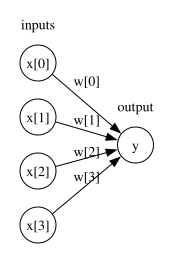

In [66]:
display(mglearn.plots.plot_logistic_regression_graph())

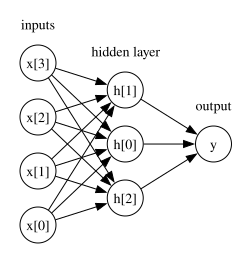

In [67]:
# showing the hidden units
display(mglearn.plots.plot_single_hidden_layer_graph())

After computing a weighted sum for each hidden unit, a nonlinear function is applied to the result. Usually the *rectifying nonlinearity* (also known as rectified linear unit or relu) or the *tangens hyperbolicus* (tanh). The result of this function is then used in the weighted sum that computes the output.

Text(0, 0.5, 'relu(x), tanh(x)')

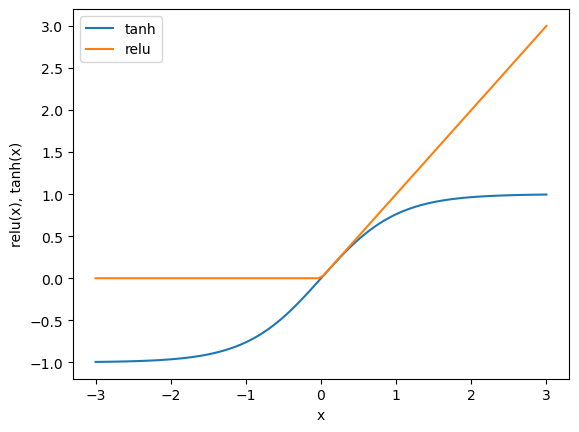

In [68]:
line = np.linspace(-3, 3, 100)
plt.plot(line, np.tanh(line), label="tanh")
plt.plot(line, np.maximum(line, 0), label="relu")
plt.legend(loc="best")
plt.xlabel("x")
plt.ylabel("relu(x), tanh(x)")

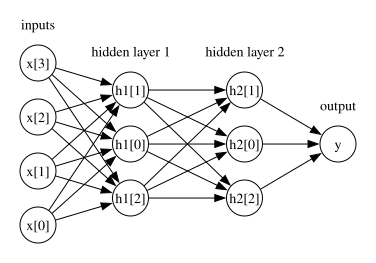

In [69]:
# another example of more complexity
mglearn.plots.plot_two_hidden_layer_graph()

Text(0, 0.5, 'Feature 1')

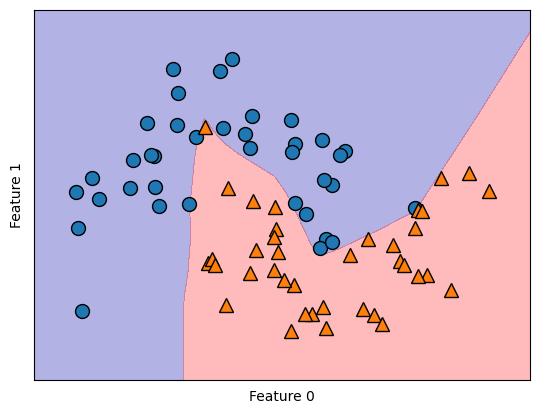

In [70]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.25, random_state=3)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, stratify=y, random_state=42)

# algorithm -> solver
mlp = MLPClassifier(solver = "lbfgs", random_state=0).fit(xtrain, ytrain)
mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3)
mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

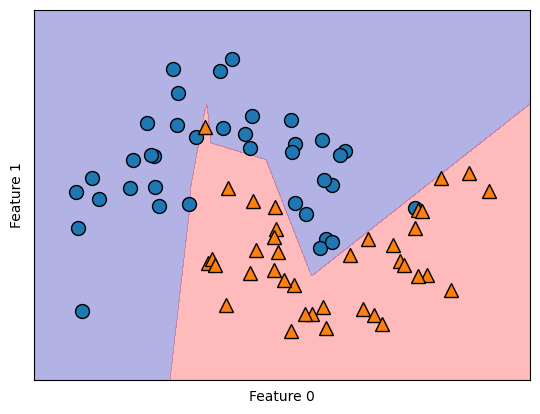

In [71]:
# use less layers
mlp = MLPClassifier(solver = "lbfgs", random_state=0, hidden_layer_sizes=[10]).fit(xtrain, ytrain)
mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3)
mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

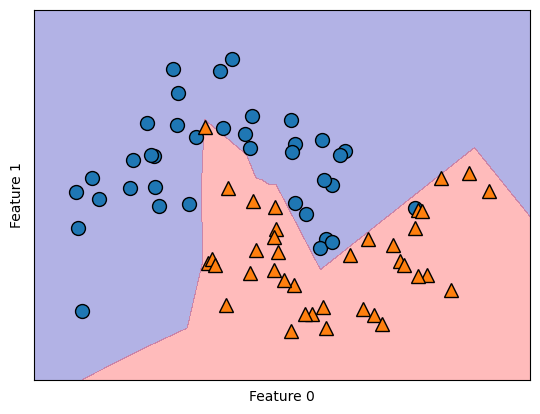

In [72]:
# use 2 layers 

mlp = MLPClassifier(solver = "lbfgs", random_state=0, hidden_layer_sizes=[10, 10]).fit(xtrain, ytrain)
mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3)
mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

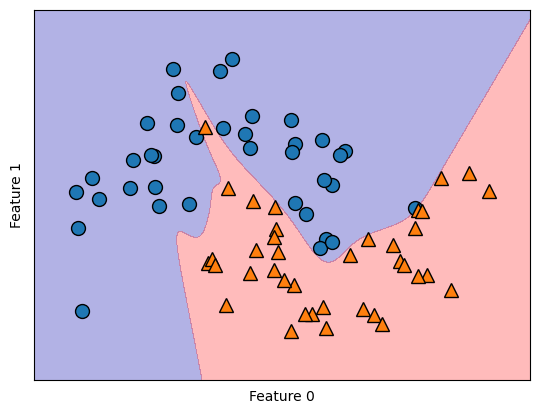

In [73]:
# implementing the tanh method
mlp = MLPClassifier(solver = "lbfgs", random_state=0, activation="tanh", hidden_layer_sizes=[10, 10]).fit(xtrain, ytrain)
mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3)
mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

We can also use a penalty that shrinks the weights toward zero, which regularizes the model

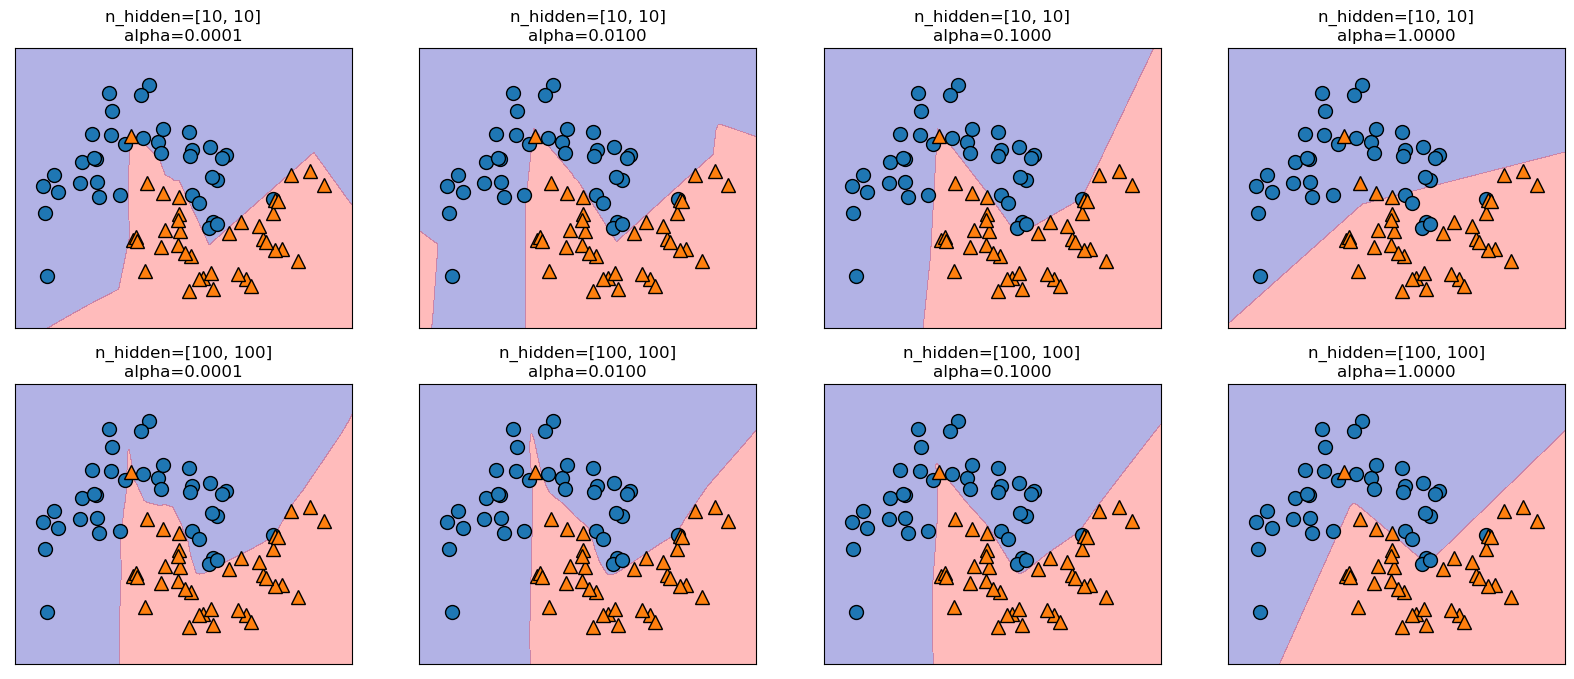

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        # the penalty (l2) is controlled with the parameter alpha
        mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes], alpha=alpha)
        mlp.fit(xtrain, ytrain)
        mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain, ax=ax)
        ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(n_hidden_nodes, n_hidden_nodes, alpha))

An important property of neural networks is that their weights are set randomly before learning is started, and this random initialization affects the model that is learned. That means that even when using exactly the same parameters, we can obtain very different models when using different random seeds.

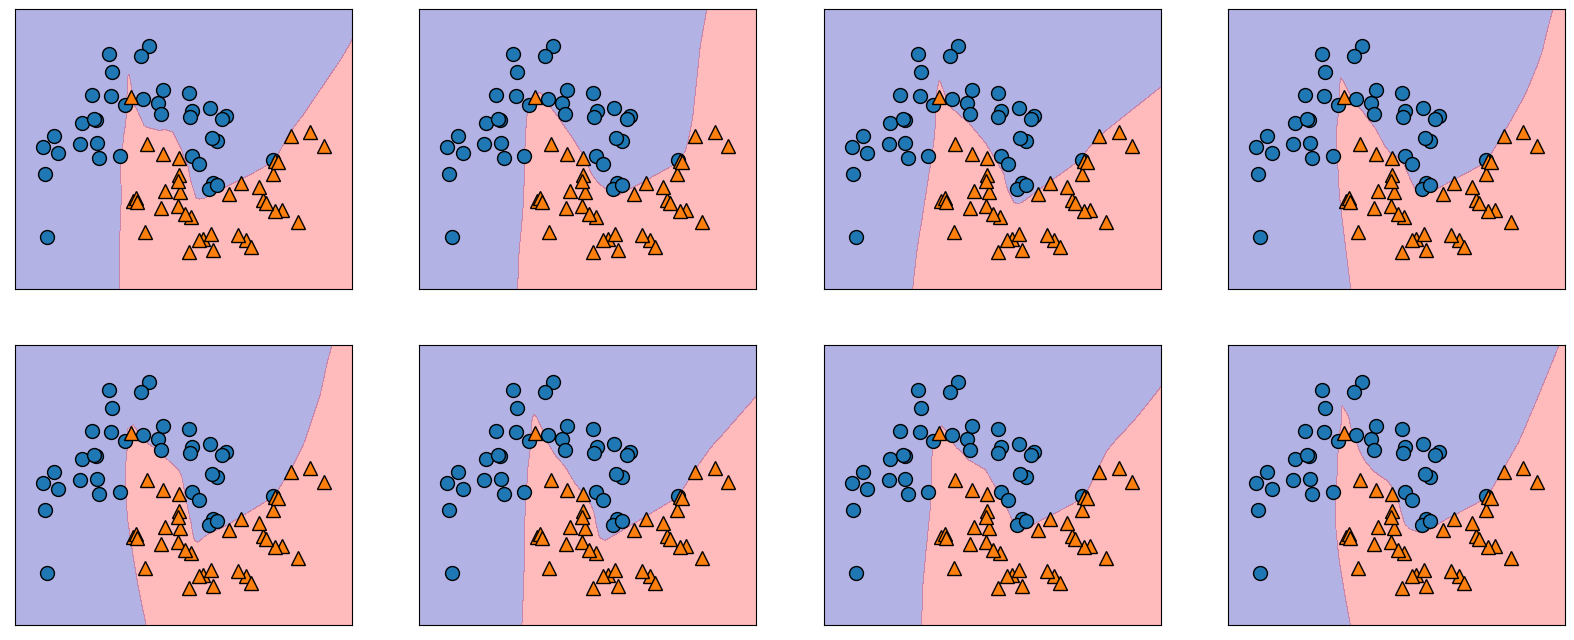

In [75]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# testing different random seeds
for i, ax in enumerate(axes.ravel()):
    mlp = MLPClassifier(solver='lbfgs', random_state=i, hidden_layer_sizes=[100, 100])
    mlp.fit(xtrain, ytrain)
    mglearn.plots.plot_2d_separator(mlp, xtrain, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain, ax=ax)

In [76]:
# Applying a neural network approach on real world data (cancer data set)
print(cancer.data.max(axis=0))

[2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


In [77]:
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, random_state=0)
mlp = MLPClassifier(random_state=42) # multilayer perceptron
mlp.fit(xtrain, ytrain)
print(mlp.score(xtrain, ytrain))
print(mlp.score(xtest, ytest))

0.9389671361502347
0.916083916083916


The above is pretty good, but not the best. Neural networks also expect all input features to vary in a similar way, and ideally to have a mean of 0 & a variance of 1. So we should rescale to see if we can improve our model

In [78]:
mean_on_train = xtrain.mean(axis = 0)
std_on_train  = xtrain.std(axis = 0)
xtrain_scaled = (xtrain - mean_on_train) / std_on_train
xtest_scaled  = (xtest - mean_on_train) / std_on_train
mlp           = MLPClassifier(random_state=0)
mlp.fit(xtrain_scaled, ytrain)
print(mlp.score(xtrain_scaled, ytrain))
print(mlp.score(xtest_scaled, ytest))

0.9906103286384976
0.965034965034965


In [79]:
# increase iterations to get around the `adam` algorithm's learning step
mlp = MLPClassifier(random_state=0, max_iter=1_000)
mlp.fit(xtrain_scaled, ytrain)
print(mlp.score(xtrain_scaled, ytrain))
print(mlp.score(xtest_scaled, ytest))

1.0
0.972027972027972


Identifying what the neural networks have learned is possible but tricky. One way to introspect what was learned is to look at the weights in the model.

Below, we will visualize the weights that were learned connecting the input to the first hidden layer. The rows will be the 30 input features while the columns correspond to the 100 hidden units. Light colors represent large positive values while dark colors represent negative values

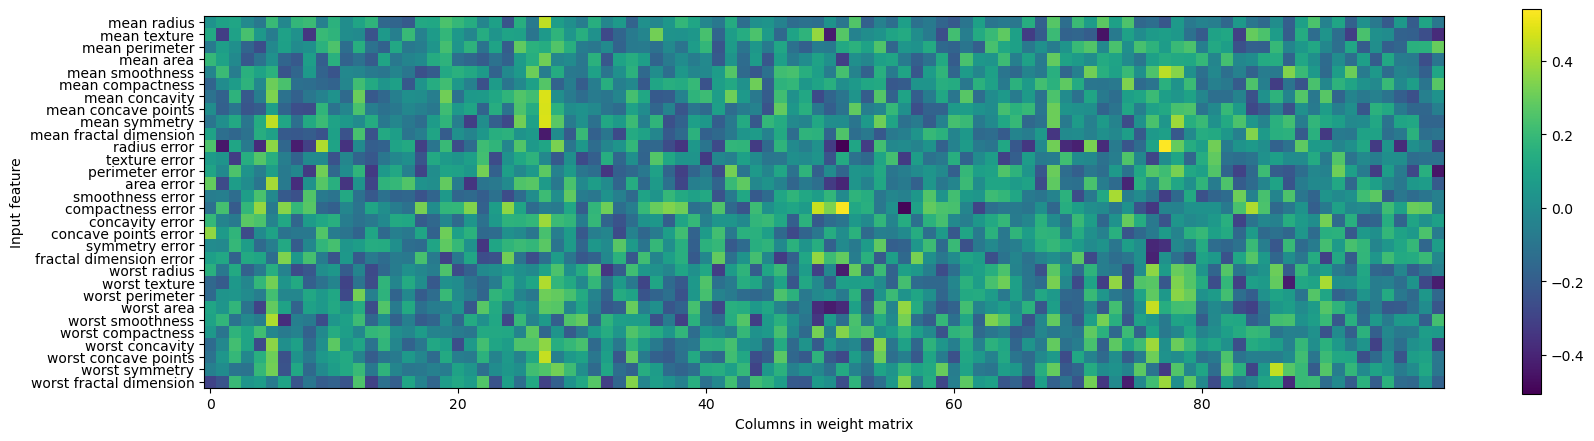

In [80]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()

Although neural networks are very powerful, they can take a while to train compared to other methods such as SVM, random forests, etc..

A very nice feature about `scikit-learn` is that their classifier classes also report back how *certain* they are for a given data point, which indirectly tells us how *uncertain* they are

In [81]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_blobs, make_circles

x, y = make_circles(noise=0.25, factor=0.5, random_state=1)

# rename classes "blue" & "red" for illustration purposes
y_renamed = np.array(["blue", "red"])[y]
xtrain, xtest, ytrain_named, ytest_named, \
    ytrain, ytest = train_test_split(x, y_renamed, y, random_state=0)

# gradient boosting model
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(xtrain, ytrain_named)

GradientBoostingClassifier(random_state=0)

In [82]:
print(xtest.shape)

# here is one function to look at the models certainty
print(gbrt.decision_function(xtest).shape) # all the decisions are here
print(gbrt.decision_function(xtest)[:6])

# Positive values indicate a preference for the positive class
# negative values indicate a preference for the "negative" (i.e., other) class

(25, 2)
(25,)
[ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]


In [83]:
# see the preference directions
print(gbrt.decision_function(xtest) > 0)
print(gbrt.predict(xtest))

[ True False False False  True  True False  True  True  True False  True
  True False  True False False False  True  True  True  True  True False
 False]
['red' 'blue' 'blue' 'blue' 'red' 'red' 'blue' 'red' 'red' 'red' 'blue'
 'red' 'red' 'blue' 'red' 'blue' 'blue' 'blue' 'red' 'red' 'red' 'red'
 'red' 'blue' 'blue']


In [84]:
# fully recovering the output of predict
greater_zero = (gbrt.decision_function(xtest) > 0).astype(int)
pred         = gbrt.classes_[greater_zero]
print(np.all(pred == gbrt.predict(xtest)))

True


In [85]:
# print the range of certainies
decision_function = gbrt.decision_function(xtest)
print(np.min(decision_function), np.max(decision_function))

-7.690971785101899 4.289866423997604


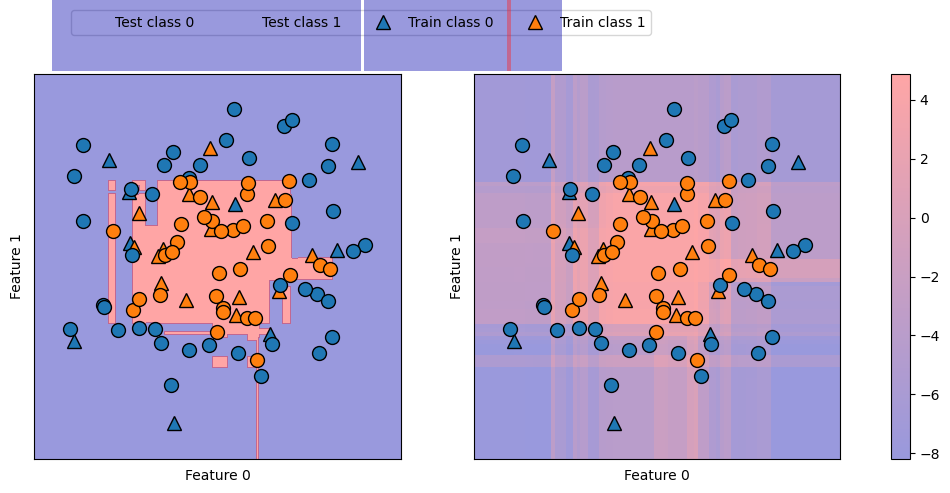

In [86]:
# plot the decision_function 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mglearn.tools.plot_2d_separator(gbrt, x, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, x, ax=axes[1], alpha=.4, cm=mglearn.ReBl)

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(xtest[:, 0], xtest[:, 1], ytest, markers='^', ax=ax)
    mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain, markers='o', ax=ax)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(["Test class 0", "Test class 1", "Train class 0", "Train class 1"], ncol=4, loc=(.1, 1.1))


In [87]:
# The other certainty function shows probability 
print(gbrt.predict_proba(xtest).shape)
print(gbrt.predict_proba(xtest[:6])) # probability of class 1 vs class 2

(25, 2)
[[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]


A model is called *calibrated* if the reported uncertainty actually matches how correct it is – in a calibrated model, a prediction made with 70% certainty would be correct 70% of the time

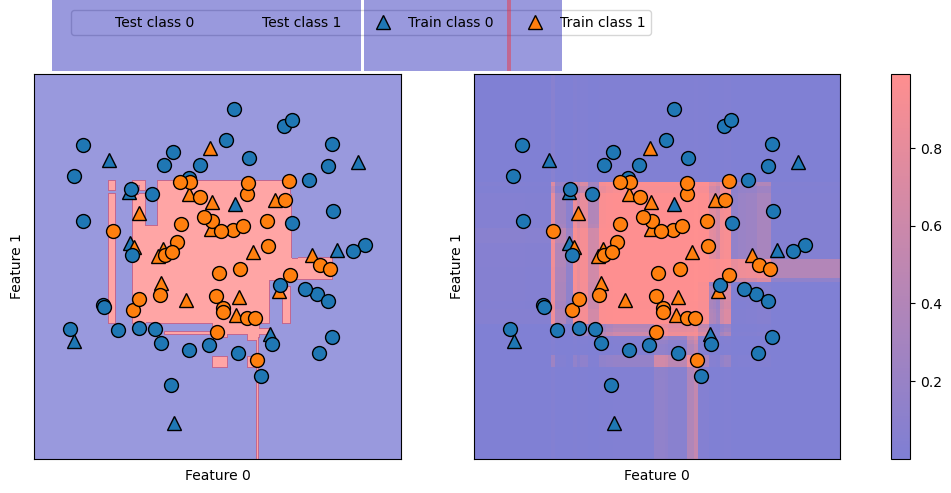

In [88]:
# visualize the probabilities
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mglearn.tools.plot_2d_separator(gbrt, x, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, x, ax=axes[1], alpha=.5, cm=mglearn.ReBl, function='predict_proba')

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(xtest[:, 0], xtest[:, 1], ytest, markers='^' , ax=ax)
    mglearn.discrete_scatter(xtrain[:, 0], xtrain[:, 1], ytrain, markers='o', ax=ax)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(["Test class 0", "Test class 1", "Train class 0", "Train class 1"], ncol=4, loc=(.1, 1.1))

In [89]:
# Looking at uncertainty in multi-class (i.e., > binary) classifications
from sklearn.datasets import load_iris

iris = load_iris()
xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, random_state=42)
gbrt = GradientBoostingClassifier(learning_rate=0.01, random_state=0)
gbrt.fit(xtrain, ytrain)

print(gbrt.decision_function(xtest).shape)
print(gbrt.decision_function(xtest)[:6, :]) # each class has a certainty score

(38, 3)
[[-1.995715    0.04758267 -1.92720695]
 [ 0.06146394 -1.90755736 -1.92793758]
 [-1.99058203 -1.87637861  0.09686725]
 [-1.995715    0.04758267 -1.92720695]
 [-1.99730159 -0.13469108 -1.20341483]
 [ 0.06146394 -1.90755736 -1.92793758]]


In [90]:
print(np.argmax(gbrt.decision_function(xtest), axis=1)) # maximum score for each data point
print(gbrt.predict(xtest))

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


In [91]:
print(gbrt.predict_proba(xtest)[:6])
print(gbrt.predict_proba(xtest)[:6].sum(axis = 1))

[[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]
 [0.10217718 0.78840034 0.10942248]
 [0.10360005 0.66723901 0.22916094]
 [0.78347147 0.10936745 0.10716108]]
[1. 1. 1. 1. 1. 1.]


In [92]:
# recover the predictions
print(np.argmax(gbrt.predict_proba(xtest), axis=1))
print(gbrt.predict(xtest))

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


In [93]:
# now just illustrating using a log regression

# some data may not have the names, but we can add them
logreg       = LogisticRegression()
named_target = iris.target_names[ytrain]
logreg.fit(xtrain, named_target)
print(logreg.classes_)
print(logreg.predict(xtest)[:10])
argmax_dec_func = np.argmax(logreg.decision_function(xtest), axis=1)
print(argmax_dec_func[:10]) # will not show class labels/names
print(logreg.classes_[argmax_dec_func][:10]) # shows class labels/names

['setosa' 'versicolor' 'virginica']
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
[1 0 2 1 1 0 1 2 1 1]
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
